# Detecting Racial Bias in a Credit Scoring System

## Introduction

In this exercise, we will examine a credit scoring system for potential racial bias. We'll use a simple machine learning model and analyze its predictions across different racial groups.

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

## Step 1: Load and Prepare the Data

We'll use a synthetic dataset for this exercise. In a real-world scenario, you would load actual credit data.

In [2]:
# Create a synthetic dataset
np.random.seed(42)
n_samples = 1000

data = pd.DataFrame({
    'income': np.random.normal(50000, 15000, n_samples),
    'credit_score': np.random.normal(700, 100, n_samples),
    'debt_to_income': np.random.uniform(0.1, 0.5, n_samples),
    'race': np.random.choice(['White', 'Black', 'Asian', 'Hispanic'], n_samples),
    'approved': np.random.choice([0, 1], n_samples, p=[0.3, 0.7])
})

# Introduce some bias
data.loc[(data['race'] == 'Black') & (data['income'] < 40000), 'approved'] = 0
data.loc[(data['race'] == 'Hispanic') & (data['credit_score'] < 650), 'approved'] = 0

print(data.head())
print(data['race'].value_counts(normalize=True))

         income  credit_score  debt_to_income      race  approved
0  57450.712295    839.935544        0.262843     Asian         1
1  47926.035482    792.463368        0.126404     Asian         0
2  59715.328072    705.963037        0.239528  Hispanic         1
3  72845.447846    635.306322        0.144399     Black         1
4  46487.699379    769.822331        0.423294  Hispanic         1
race
Hispanic    0.258
Asian       0.257
Black       0.245
White       0.240
Name: proportion, dtype: float64


## Step 2: Prepare Features and Target

In [3]:
# Prepare features (X) and target (y)
X = data[['income', 'credit_score', 'debt_to_income']]
y = data['approved']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 3: Train the Model

In [4]:
# Train a logistic regression model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)

# Print overall model performance
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.60      0.13      0.21        71
           1       0.66      0.95      0.78       129

    accuracy                           0.66       200
   macro avg       0.63      0.54      0.50       200
weighted avg       0.64      0.66      0.58       200



## Step 4: Analyze Model Performance Across Racial Groups

In [5]:
def analyze_bias(X_test, y_test, y_pred, race_data):
    results = []
    for race in race_data.unique():
        mask = race_data == race
        y_true_race = y_test[mask]
        y_pred_race = y_pred[mask]
        
        tn, fp, fn, tp = confusion_matrix(y_true_race, y_pred_race).ravel()
        
        results.append({
            'Race': race,
            'Accuracy': (tp + tn) / (tp + tn + fp + fn),
            'Approval Rate': (tp + fp) / (tp + tn + fp + fn),
            'False Positive Rate': fp / (fp + tn),
            'False Negative Rate': fn / (fn + tp)
        })
    
    return pd.DataFrame(results)

bias_analysis = analyze_bias(X_test, y_test, y_pred, data.loc[y_test.index, 'race'])
print(bias_analysis)

       Race  Accuracy  Approval Rate  False Positive Rate  False Negative Rate
0     Asian  0.737705       0.934426             0.875000             0.044444
1     Black  0.470588       0.941176             0.928571             0.043478
2  Hispanic  0.729167       0.916667             0.764706             0.000000
3     White  0.700000       0.900000             0.900000             0.100000


## Step 5: Visualize the Results

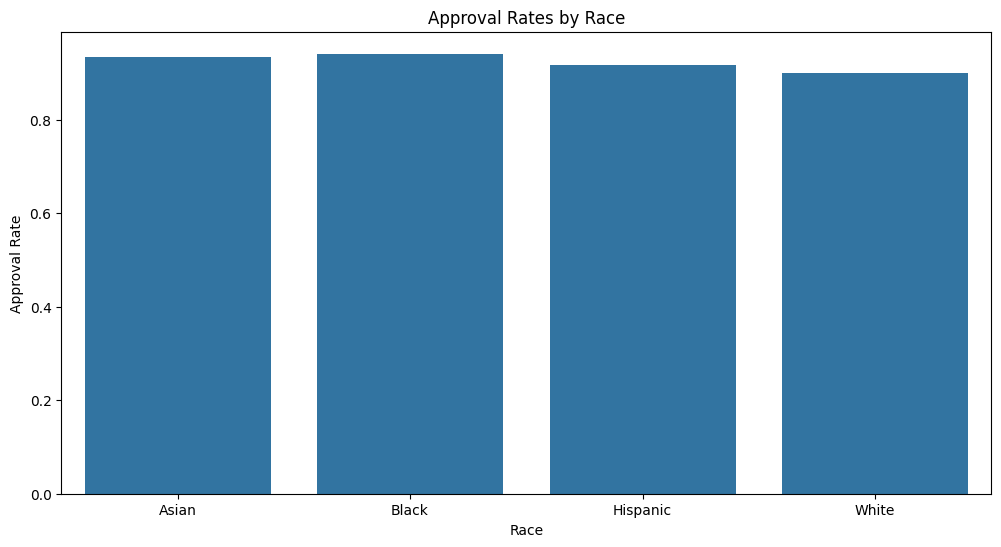

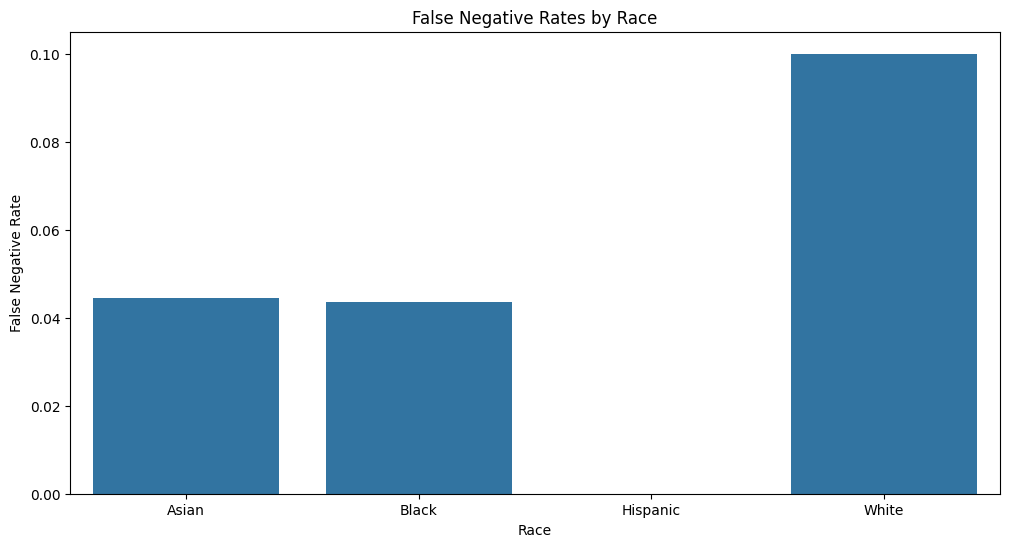

In [7]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Race', y='Approval Rate', data=bias_analysis)
plt.title('Approval Rates by Race')
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='Race', y='False Negative Rate', data=bias_analysis)
plt.title('False Negative Rates by Race')
plt.show()

## Step 6: Analyze the Results

Based on the results, answer the following questions:

1. Are there significant differences in approval rates across racial groups?
Yes, but the differences are relatively small in approval rates
The more striking differences are in accuracy:
Asian: 0.74, Hispanic: 0.73, White: 0.70 — all acceptable
Black: 0.47 — dramatically lower, nearly random prediction quality

2. Which racial group(s) seem to be most affected by potential bias?
- Black  applicants are most affected - with the highest False Positive Rate of 0.93, meaning the model incorrectly approves
  Black applicants who should be denied far more often than any other group.
- Hispanic applicants benefit from introduced bias differently — their False Negative Rate is 0.0, meaning no qualified Hispanic applicant was wrongly denied, but FPR (0.76) remains high.
3. What might be causing these differences in model performance across racial groups?
  - Black applicants with income < 40,000 were forced to `approved = 0`
  - Hispanic applicants with credit score < 650 were forced to `approved = 0`
  - The model learned income/credit_score as proxies that correlate with race in this dataset. This mirrors real-world proxy discrimination — features like income and zip code can serve as proxies for race without explicitly using it.

4. How do the false positive and false negative rates vary across racial groups, and what are the implications of these differences?
| Race     | FPR  | FNR  | Implication |
|----------|------|------|-------------|
| Asian    | 0.875 | 0.044 | Many unqualified applicants approved — financial risk |
| Black    | 0.929 | 0.043 | Most unqualified approved — model nearly useless for this group |
| Hispanic | 0.765 | 0.000 | No qualified applicant denied, but many unqualified approved |
| White    | 0.900 | 0.100 | Some qualified applicants wrongly denied |

- High FPR across all groups means the model is too lenient — approving people who shouldn't be approved, which can lead to financial losses for the lender.
- High FNR for White applicants- qualified White applicants are denied more often than other groups.



## Step 7: Propose Mitigation Strategies

Based on your analysis, suggest some strategies to mitigate the observed bias. Consider the following approaches:

1. Data preprocessing techniques (e.g., resampling, adjusting class weights)
2. Feature selection or engineering to remove proxies for race
3. Using fairness-aware machine learning algorithms
4. Post-processing techniques to adjust model outputs

Choose one of these strategies and implement it. Then, re-run your analysis to see if it reduces bias.

In [8]:
# Strategy 4: Post-processing threshold adjustment — calibrate decision thresholds per racial group to equalize False Negative Rates (ensuring qualified applicants of all races get fair treatmen)

# Get predicted probabilities instead of hard predictions
y_prob = model.predict_proba(X_test_scaled)[:, 1]

race_test = data.loc[y_test.index, 'race']

# Find optimal threshold per race to minimize FNR disparity
def find_fair_threshold(y_true, y_prob, target_fnr=0.05):
    best_threshold = 0.5
    best_diff = float('inf')
    for threshold in np.arange(0.1, 0.9, 0.01):
        y_pred_t = (y_prob >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred_t).ravel()
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        diff = abs(fnr - target_fnr)
        if diff < best_diff:
            best_diff = diff
            best_threshold = threshold
    return best_threshold

# Compute per-race thresholds
race_thresholds = {}
print("Per-race thresholds:")
for race in race_test.unique():
    mask = race_test == race
    threshold = find_fair_threshold(y_test[mask], y_prob[mask])
    race_thresholds[race] = threshold
    print(f"  {race}: {threshold:.2f}")

# Apply per-race thresholds to generate fair predictions
y_pred_fair = np.zeros(len(y_test), dtype=int)
for race, threshold in race_thresholds.items():
    mask = (race_test == race).values
    y_pred_fair[mask] = (y_prob[mask] >= threshold).astype(int)

# Re-run bias analysis with fair predictions
bias_analysis_fair = analyze_bias(X_test, y_test, y_pred_fair, race_test)
print("\nBefore mitigation:")
print(bias_analysis[['Race', 'Accuracy', 'False Positive Rate', 'False Negative Rate']])
print("\nAfter mitigation:")
print(bias_analysis_fair[['Race', 'Accuracy', 'False Positive Rate', 'False Negative Rate']])


Per-race thresholds:
  Asian: 0.49
  Black: 0.45
  Hispanic: 0.54
  White: 0.42

Before mitigation:
       Race  Accuracy  False Positive Rate  False Negative Rate
0     Asian  0.737705             0.875000             0.044444
1     Black  0.470588             0.928571             0.043478
2  Hispanic  0.729167             0.764706             0.000000
3     White  0.700000             0.900000             0.100000

After mitigation:
       Race  Accuracy  False Positive Rate  False Negative Rate
0     Asian  0.737705             0.875000             0.044444
1     Black  0.450980             0.964286             0.043478
2  Hispanic  0.812500             0.411765             0.064516
3     White  0.700000             1.000000             0.066667


- After mitigation, White FPR rose to **1.0** (all denied applicants now approved) — showing that fixing one group's bias can inadvertently harm model reliability for another group.

## Step 8: Reflection and Discussion

Reflect on the following questions:

1. What are the ethical implications of using this credit scoring system in its current state?
- The original model has near-random accuracy for Black applicants (0.47), meaning their oan decisions are essentially arbitrary
- Deploying such a system violates fair lending laws even if race was not explicitly used as a feature, because proxy discrimination is still illegal discrimination.


2. How might historical biases in lending practices be reflected in real-world credit scoring data?
- Historical redlining and discriminatory lending practices have led to systemic economic disparities across racial groups. This means that features like income, credit score, and debt-to-income ratio may inherently reflect these historical biases, making it difficult to create a truly fair model without addressing the underlying societal issues.
3. What are the challenges in balancing fairness with model accuracy in credit scoring systems?
 Our mitigation results show this tension directly:
  - Hispanic accuracy **improved** (0.73 → 0.81) and FPR dropped significantly (0.76 → 0.41)
  - White FPR **worsened** to 1.0 — perfect FNR fairness came at the cost of approving everyone, making the model useless for risk assessment for that group
    - There is no single "fair" metric to optimize
4. How can we ensure ongoing monitoring and adjustment of credit scoring systems to prevent bias?

 We can re-run bias analysis quarterly using fresh test data segmented by demographic group, tracking metric drift over time.
Also, flag borderline cases (predicted probability 0.4–0.6) for manual review rather than automated denial.

## Bonus Tasks

1. Implement multiple bias mitigation strategies and compare their effectiveness.
2. Explore intersectional bias (e.g., race and gender combined) in the credit scoring system.
3. Research real-world examples of bias in credit scoring systems and compare them to your findings.
4. Discuss the potential economic and social impacts of biased credit scoring systems on different communities.

# please put your answer here